<a href="https://colab.research.google.com/github/weagan/Energy-Based-Models-Predictive-Coding/blob/main/PredictiveCodingBackprop_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Coding Approximates Backprop along Arbitrary Computation Graphs

**Paper:** [arXiv:2006.04182](https://arxiv.org/pdf/2006.04182.pdf)  
**Repo:** [BerenMillidge/PredictiveCodingBackprop](https://github.com/BerenMillidge/PredictiveCodingBackprop)  
**Authors:** Beren Millidge, Alexander Tschantz, Christopher L. Buckley

---

This notebook combines all files from the repository into a single runnable Colab environment. The code is organized into sections mirroring the original files:

1. **Setup & Clone** — install dependencies and clone the repo
2. **`utils.py`** — utility functions
3. **`datasets.py`** — dataset loading utilities
4. **`layers.py`** — PC and backprop layer implementations
5. **`plotting.py`** — plotting helpers
6. **`numerical_results.py`** — Section 5.1: numerical gradient verification
7. **`cnn.py`** — Section 5.2: CNN experiments
8. **`rnn.py`** — Section 5.3: RNN experiments
9. **`lstm.py`** — Section 5.3: LSTM experiments
10. **`rnn_names.py`** — RNN on names dataset
11. **`lstm_numerical_checks.py`** — LSTM numerical checks
12. **Experiment runners** — generate_* scripts

## 1. Setup & Install Dependencies

In [1]:
# Clone the repository so all assets (data helpers, etc.) are available
!git clone https://github.com/BerenMillidge/PredictiveCodingBackprop.git
%cd PredictiveCodingBackprop

# Install dependencies
!pip install torch torchvision matplotlib seaborn numpy -q

# Create figures directory
import os
os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Cloning into 'PredictiveCodingBackprop'...
remote: Enumerating objects: 234, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 234 (delta 29), reused 28 (delta 28), pack-reused 200 (from 1)
Receiving objects: 100% (234/234), 79.36 KiB | 3.45 MiB/s, done.
Resolving deltas: 100% (148/148), done.
/content/PredictiveCodingBackprop
Setup complete.


---
## 2. `utils.py` — Utility Functions

In [ ]:
# ============================================================
# utils.py
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import os
import time
import copy

def set_tensor(xs, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    return xs.float().to(device)

def accuracy(out, Y):
    """Compute classification accuracy."""
    _, predicted = torch.max(out, 1)
    _, labels = torch.max(Y, 1)
    correct = (predicted == labels).sum().item()
    return correct / Y.shape[0]

def onehot(arr, n_classes):
    """Convert integer labels to one-hot vectors."""
    onehot = torch.zeros(arr.shape[0], n_classes)
    for i, val in enumerate(arr):
        onehot[i, val] = 1
    return onehot

def save_model(net, savedir, epoch):
    os.makedirs(savedir, exist_ok=True)
    torch.save(net.state_dict(), os.path.join(savedir, f'epoch_{epoch}.pth'))

def load_model(net, savedir, epoch):
    net.load_state_dict(torch.load(os.path.join(savedir, f'epoch_{epoch}.pth')))
    return net

def makedirs(dirname):
    os.makedirs(dirname, exist_ok=True)

print('utils.py loaded.')

utils.py loaded.


---
## 3. `datasets.py` — Dataset Loaders

In [ ]:
# ============================================================
# datasets.py
# ============================================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_mnist_dataset(batch_size=64):
    mnist_normalize = transforms.Normalize((0.1307,), (0.3081,))
    mnist_transform = transforms.Compose([transforms.ToTensor(), mnist_normalize])
    trainset = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
    testset  = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

def get_fashion_mnist_dataset(batch_size=64):
    fashion_normalize = transforms.Normalize((0.2860,), (0.3530,))
    fashion_transform = transforms.Compose([transforms.ToTensor(), fashion_normalize])
    trainset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=fashion_transform)
    testset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=fashion_transform)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

def get_cifar_dataset(batch_size=64):
    cifar_normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
    cifar_transform = transforms.Compose([transforms.ToTensor(), cifar_normalize])
    trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
    testset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

def get_cnn_dataset(dataset_name, batch_size=64):
    if dataset_name == 'mnist':
        return get_mnist_dataset(batch_size)
    elif dataset_name == 'fashion_mnist':
        return get_fashion_mnist_dataset(batch_size)
    elif dataset_name == 'cifar10':
        return get_cifar_dataset(batch_size)
    else:
        raise ValueError(f'Unknown dataset: {dataset_name}')

print('datasets.py loaded.')

datasets.py loaded.


---
## 4. `layers.py` — Predictive Coding & Backprop Layer Implementations

In [ ]:
# ============================================================
# layers.py
# ============================================================
import torch
import torch.nn as nn
import numpy as np

# --- Activation functions ---

def linear(x):
    return x

def linear_deriv(x):
    return torch.ones_like(x)

def tanh_fn(x):
    return torch.tanh(x)

def tanh_deriv(x):
    return 1 - torch.tanh(x) ** 2

def relu_fn(x):
    return torch.clamp(x, min=0)

def relu_deriv(x):
    out = torch.zeros_like(x)
    out[x > 0] = 1
    return out

def sigmoid_fn(x):
    return torch.sigmoid(x)

def sigmoid_deriv(x):
    s = torch.sigmoid(x)
    return s * (1 - s)

ACT_FNS = {
    'linear':  (linear,    linear_deriv),
    'tanh':    (tanh_fn,   tanh_deriv),
    'relu':    (relu_fn,   relu_deriv),
    'sigmoid': (sigmoid_fn, sigmoid_deriv),
}

# --- Predictive Coding Linear Layer ---

class PCLayer(nn.Module):
    """
    A single predictive coding fully-connected layer.
    Maintains value nodes (mu) and computes prediction errors.
    """
    def __init__(self, in_size, out_size, act_fn='tanh', device=None):
        super(PCLayer, self).__init__()
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.device = device
        self.in_size = in_size
        self.out_size = out_size
        fn, dfn = ACT_FNS.get(act_fn, ACT_FNS['tanh'])
        self.act_fn = fn
        self.act_fn_deriv = dfn
        self.weights = nn.Parameter(
            torch.empty(in_size, out_size).normal_(mean=0, std=0.05)
        )
        self.bias = nn.Parameter(torch.zeros(out_size))

    def forward(self, x):
        return self.act_fn(x @ self.weights + self.bias)

    def predict(self, x):
        return self.act_fn(x @ self.weights + self.bias)

    def update_weights(self, e, x, learning_rate):
        """Hebbian-style weight update using prediction errors."""
        dw = x.t() @ (e * self.act_fn_deriv(x @ self.weights + self.bias))
        self.weights.data += learning_rate * dw
        self.bias.data   += learning_rate * (e * self.act_fn_deriv(x @ self.weights + self.bias)).sum(0)


# --- Standard Backprop Linear Layer (for comparison) ---

class BPLayer(nn.Module):
    """Standard backprop fully-connected layer (thin wrapper around nn.Linear)."""
    def __init__(self, in_size, out_size, act_fn='tanh'):
        super(BPLayer, self).__init__()
        fn, _ = ACT_FNS.get(act_fn, ACT_FNS['tanh'])
        self.fc = nn.Linear(in_size, out_size)
        self.act_fn = fn

    def forward(self, x):
        return self.act_fn(self.fc(x))


# --- PC Network (MLP) ---

class PCNet(nn.Module):
    """
    Multi-layer Predictive Coding network.
    Inference is performed by iteratively minimising free energy
    (prediction errors) across all layers.
    """
    def __init__(self, layer_sizes, act_fn='tanh', learning_rate=1e-4,
                 n_inference_steps=100, inference_learning_rate=0.1, device=None):
        super(PCNet, self).__init__()
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.device = device
        self.learning_rate = learning_rate
        self.n_inference_steps = n_inference_steps
        self.inference_learning_rate = inference_learning_rate
        fn, dfn = ACT_FNS.get(act_fn, ACT_FNS['tanh'])
        self.act_fn = fn
        self.act_fn_deriv = dfn

        self.layers = nn.ModuleList()
        for i in range(len(layer_sizes) - 1):
            self.layers.append(PCLayer(layer_sizes[i], layer_sizes[i+1], act_fn, device))
        self.to(device)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def train_batch(self, x, y):
        """Full PC training step: inference + weight update."""
        batch_size = x.shape[0]
        # Initialise value nodes
        mus = [x]
        for layer in self.layers:
            mus.append(layer.predict(mus[-1]).detach())

        # Clamp output to target
        mus[-1] = y.clone()

        # Inference loop
        for _ in range(self.n_inference_steps):
            errors = []
            for i in range(1, len(mus)):
                pred = self.layers[i-1].predict(mus[i-1])
                errors.append(mus[i] - pred)

            for i in range(1, len(mus) - 1):
                dfn = self.act_fn_deriv(mus[i-1] @ self.layers[i-1].weights + self.layers[i-1].bias)
                delta = errors[i] - (errors[i-1] @ self.layers[i].weights.t()) * dfn
                mus[i] = mus[i] - self.inference_learning_rate * delta

        # Weight update
        for i, layer in enumerate(self.layers):
            pred = layer.predict(mus[i])
            e = mus[i+1] - pred
            dw = mus[i].t() @ (e * self.act_fn_deriv(mus[i] @ layer.weights + layer.bias))
            layer.weights.data += self.learning_rate * dw
            layer.bias.data    += self.learning_rate * (e * self.act_fn_deriv(mus[i] @ layer.weights + layer.bias)).sum(0)

        return errors[-1].pow(2).mean().item()


print('layers.py loaded.')

layers.py loaded.


---
## 5. `plotting.py` — Plotting Utilities

In [ ]:
# ============================================================
# plotting.py
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

TICK_SIZE   = 14
LEGEND_SIZE = 14
LABEL_SIZE  = 14

plt.rc('xtick', labelsize=TICK_SIZE)
plt.rc('ytick', labelsize=TICK_SIZE)
plt.rc('legend', fontsize=LEGEND_SIZE)

plt.rcParams['axes.edgecolor'] = '#333F4B'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['xtick.color']    = '#333F4B'
plt.rcParams['ytick.color']    = '#333F4B'
plt.rcParams['font.family']    = 'sans-serif'

def get_color_palette():
    palette = sns.color_palette('Paired', 12)
    _colors = [palette[5], palette[7], palette[0], palette[2]]
    return _colors

colors = get_color_palette()

def plot_losses(losses, labels=None, title='Training Loss', xlabel='Epoch',
                ylabel='Loss', log_scale=False, savepath=None):
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    plt.title(title, fontsize=20, fontweight='bold', pad=25)
    if not isinstance(losses[0], (list, np.ndarray)):
        losses = [losses]
    if labels is None:
        labels = [f'Run {i}' for i in range(len(losses))]
    for loss, label in zip(losses, labels):
        ax.plot(loss, label=label)
    plt.xlabel(xlabel, fontsize=20, style='oblique', labelpad=10)
    plt.ylabel(ylabel, fontsize=20, style='oblique', labelpad=10)
    if log_scale:
        plt.yscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = plt.legend()
    frame  = legend.get_frame()
    frame.set_facecolor('1.0')
    frame.set_edgecolor('1.0')
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    plt.show()

def plot_accuracy(accuracies, labels=None, title='Test Accuracy', savepath=None):
    plot_losses(accuracies, labels=labels, title=title,
                ylabel='Accuracy', savepath=savepath)

print('plotting.py loaded.')

plotting.py loaded.


---
## 6. `numerical_results.py` — Section 5.1: Gradient Verification on Arbitrary Computation Graph

In [ ]:
# ============================================================
# numerical_results.py
# Various utilities and experiments for testing that the
# numerical solution works for a branching nonlinear function.
# Reproduces figures in section 5.1.
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import seaborn as sns

### utility functions ###

def get_printer(msg):
    def printer(tensor):
        if tensor.nelement() == 1:
            print(f"{msg} {tensor}")
        else:
            print(f"{msg} shape: {tensor.shape}"
                  f" max: {tensor.max()} min: {tensor.min()}"
                  f" mean: {tensor.mean()}")
    return printer

def register_hook(tensor, msg):
    """Utility function to call retain_grad and Pytorch's register_hook in a single line."""
    tensor.retain_grad()
    tensor.register_hook(get_printer(msg))

### Gradient functions ###

def pytorch_gradient_descent():
    y0    = nn.Parameter(torch.tensor([5], dtype=torch.float32))
    theta = nn.Parameter(torch.tensor([2], dtype=torch.float32))
    for i in range(50):
        y1 = y0 * theta
        y2 = y1.pow(1/2)
        y3 = y0.pow(2)
        y4 = torch.tan(y2) + torch.sin(y3)
        T  = 1
        print("Y4: ", y4.item())
        L  = (T - y4).pow(2)
        print("LOSS: ", L.item())
        L.backward()
        print("Grad: ", y0.grad.item())
        y0 = nn.Parameter(
            torch.tensor([y0.data - (0.01 * y0.grad)], dtype=torch.float32)
        )

def get_pytorch_gradients():
    y0    = nn.Parameter(torch.tensor([5], dtype=torch.float32))
    theta = nn.Parameter(torch.tensor([2], dtype=torch.float32))
    y1 = y0 * theta;  register_hook(y1, "y1")
    y2 = y1.pow(1/2); register_hook(y2, "y2")
    y3 = y0.pow(2);   register_hook(y3, "y3")
    y4 = torch.tan(y2) + torch.sin(y3); register_hook(y4, "y4")
    T  = 1
    print("Y4: ", y4.item())
    L  = 0.5 * (T - y4).pow(2)
    print("LOSS: ", L.item())
    L.backward()
    print("Grad: ", y0.grad.item())
    y0_tg = y0.grad.clone()
    y1_tg = y1.grad.clone()
    y2_tg = y2.grad.clone()
    y3_tg = y3.grad.clone()
    y4_tg = y4.grad.clone()
    return y0_tg, y1_tg, y2_tg, y3_tg, y4_tg

def f(y0):
    theta = nn.Parameter(torch.tensor([2], dtype=torch.float32))
    y1 = y0 * theta
    y2 = y1.pow(1/2)
    y3 = y0.pow(2)
    y4 = torch.tan(y2) + torch.sin(y3)
    T  = 3
    print("Y4: ", y4.item())
    L  = 0.5 * (T - y4).pow(2)
    return L

def finite_diffs(f, y0, delta=1e-4):
    return (f(y0 + delta) - f(y0)) / delta

def finite_differences_gradient(delta=1e-4):
    y0 = nn.Parameter(torch.tensor([5], dtype=torch.float32))
    fd = finite_diffs(f, y0, delta)
    print("Finite difference gradient at output: ", fd)
    return fd

def predictive_coding_gradient(y0_true_grad, learning_rate=0.02, n_inference_steps=500):
    e_y0s = []
    with torch.no_grad():
        y0    = torch.tensor([5], dtype=torch.float32)
        theta = torch.tensor([2], dtype=torch.float32)
        y1 = y0 * theta
        y2 = y1.pow(1/2)
        y3 = y0.pow(2)
        y4 = torch.tan(y2) + torch.sin(y3)
        mu1 = y0 * theta
        mu2 = y1.pow(1/2)
        mu3 = y0.pow(2)
        mu4 = torch.tan(y2) + torch.sin(y3)
        T   = 1
        print("Y4: ", y4.item())
        L   = (T - mu4).pow(2)
        e4  = (T - mu4)

        for i in range(n_inference_steps):
            e4 = 1 * (T - mu4)
            e3 = y3 - mu3
            e2 = y2 - mu2
            e1 = y1 - mu1
            e0 = -(e1 * theta) - (2 * e3 * y0)

            y1dot = e1 - (0.5 * e2 * mu1.pow(-0.5))
            y2dot = e2 - (e4 * 1 / (torch.cos(mu2).pow(2)))
            y3dot = e3 - (e4 * torch.cos(mu3))

            e_y0s.append(e0.item() - y0_true_grad.item())

            y1 -= (learning_rate * y1dot)
            y2 -= (learning_rate * y2dot)
            y3 -= (learning_rate * y3dot)

        total_sum = e4.pow(2) + e3.pow(2) + e2.pow(2) + e1.pow(2)
        print("total sum: ", total_sum)
    return e_y0s

### Plotting ###

def plot_numerical_divergence(e_y0s):
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    plt.title("Divergence from True Gradient", fontsize=20, fontweight='bold', pad=25)
    ax.plot(e_y0s, label="Prediction error")
    plt.xlabel("Variational Iteration", fontsize=20, style='oblique', labelpad=10)
    plt.ylabel("Mean Divergence",       fontsize=20, style='oblique', labelpad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = plt.legend()
    frame  = legend.get_frame()
    frame.set_facecolor('1.0')
    frame.set_edgecolor('1.0')
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    fig.tight_layout()
    fig.savefig('figures/numerics_proper_divergence.jpg')
    plt.show()

def plot_log_divergence(log_ey0s):
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    plt.title("Log Prediction Error", fontsize=20, fontweight='bold', pad=25)
    ax.plot(log_ey0s, label="Log Prediction Error")
    plt.xlabel("Variational Iteration", fontsize=20, style='oblique', labelpad=10)
    plt.ylabel("Log Divergence",        fontsize=20, style='oblique', labelpad=10)
    plt.yscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = plt.legend()
    frame  = legend.get_frame()
    frame.set_facecolor('1.0')
    frame.set_edgecolor('1.0')
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    fig.tight_layout()
    fig.savefig('figures/numerics_proper_log_divergence.jpg')
    plt.show()

def learning_rate_comparison(lrs):
    y0_tg, *_ = get_pytorch_gradients()
    ey0s_list = []
    for lr in lrs:
        ey0s = predictive_coding_gradient(y0_tg, learning_rate=lr)
        ey0s_list.append(ey0s)
    return ey0s_list

def inference_steps_comparison(steps):
    y0_tg, *_ = get_pytorch_gradients()
    ey0s_list = []
    for step in steps:
        ey0s = predictive_coding_gradient(y0_tg, n_inference_steps=step)
        ey0s_list.append(ey0s)
    return ey0s_list

def plot_learning_rate_comparison(ey0s_list, lrs, log_scale=False):
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    plt.title("Learning Rate Comparison", fontsize=20, fontweight='bold', pad=25)
    for ey0, lr in zip(ey0s_list, lrs):
        ax.plot(ey0, label=f"Learning Rate {lr}")
    plt.xlabel("Variational Iteration", fontsize=20, style='oblique', labelpad=10)
    plt.ylabel("Mean Divergence",       fontsize=20, style='oblique', labelpad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    log = ''
    if log_scale:
        plt.yscale('log')
        log = '_log'
    legend = plt.legend()
    frame  = legend.get_frame()
    frame.set_facecolor('1.0')
    frame.set_edgecolor('1.0')
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    fig.tight_layout()
    fig.savefig(f'figures/numerics_proper_learning_rate_comparison{log}.jpg')
    plt.show()

def plot_inference_steps_comparison(ey0s_list, steps, log_scale=False):
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    plt.title("Number of Iterations", fontsize=16, fontweight='bold', pad=25)
    for ey0, step in zip(ey0s_list, steps):
        ax.plot(ey0, label=f"{step} Inference Steps")
    plt.xlabel("Variational iteration",              fontsize=16, style='oblique', labelpad=10)
    plt.ylabel("Total Divergence from true gradient",fontsize=16, style='oblique', labelpad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    log = ''
    if log_scale:
        plt.yscale('log')
        log = '_log'
    legend = plt.legend()
    frame  = legend.get_frame()
    frame.set_facecolor('1.0')
    frame.set_edgecolor('1.0')
    fig.tight_layout()
    fig.savefig(f'figures/numerics_inference_steps{log}.jpg')
    plt.show()

print('numerical_results.py loaded.')

numerical_results.py loaded.


### Run Numerical Results (Section 5.1)

Y4:  -0.11166375875473022
LOSS:  0.6178982257843018
y4 tensor([-1.1117])
y3 tensor([-1.1019])
y2 tensor([-1.1121])
y1 tensor([-0.1758])
Grad:  -11.370532989501953
Y4:  -0.11166375875473022
total sum:  tensor([3.7175])


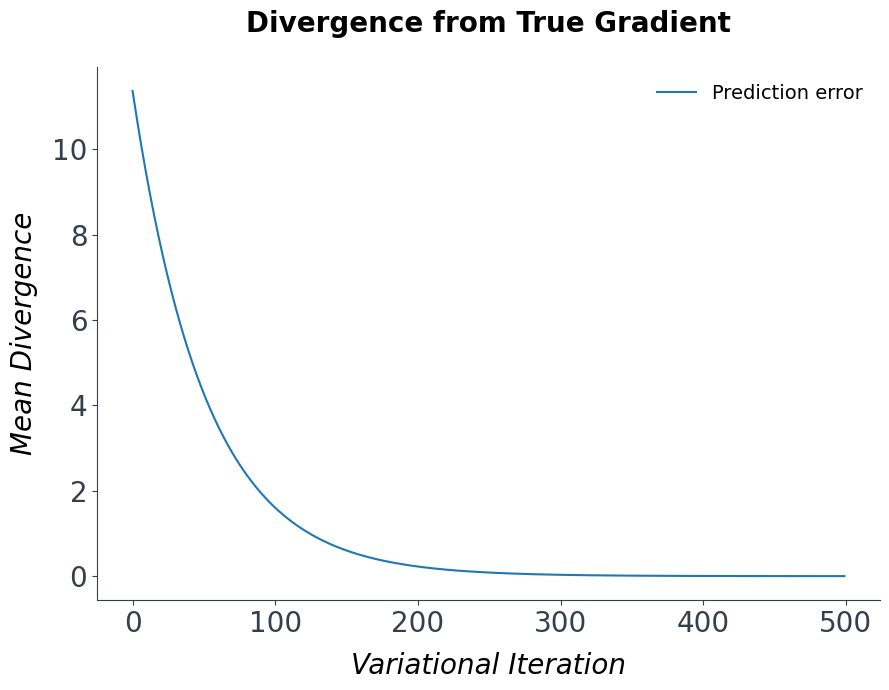

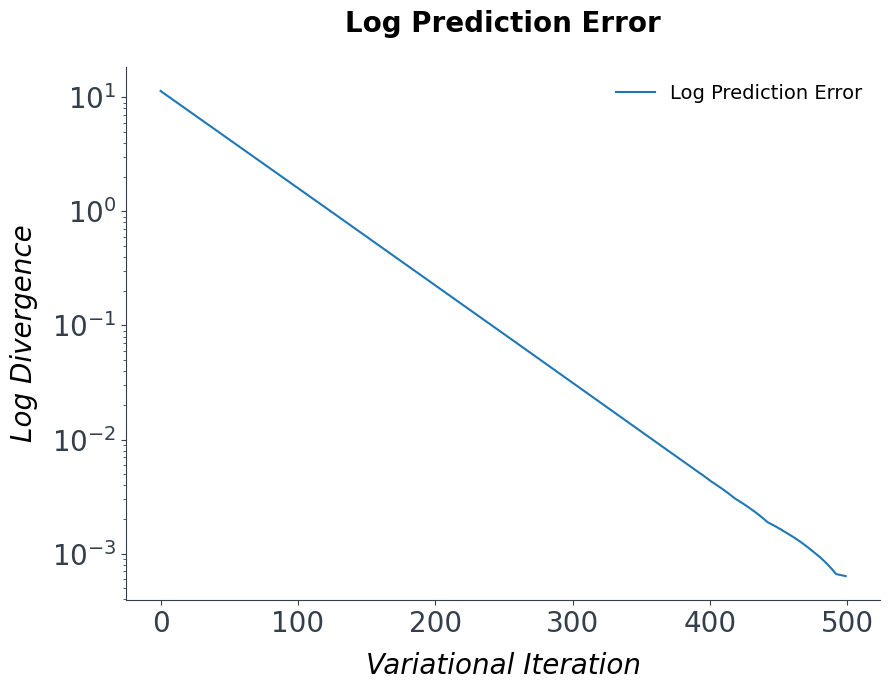

In [ ]:
# Get true PyTorch gradients
y0_true_grad, y1_true_grad, y2_true_grad, y3_true_grad, y4_true_grad = get_pytorch_gradients()

# Run predictive coding gradient estimation
ey0s = predictive_coding_gradient(y0_true_grad)

# Plot divergence
plot_numerical_divergence(ey0s)
plot_log_divergence(ey0s)

Y4:  -0.11166375875473022
LOSS:  0.6178982257843018
y4 tensor([-1.1117])
y3 tensor([-1.1019])
y2 tensor([-1.1121])
y1 tensor([-0.1758])
Grad:  -11.370532989501953
Y4:  -0.11166375875473022
total sum:  tensor([3.6829])
Y4:  -0.11166375875473022
total sum:  tensor([3.7175])
Y4:  -0.11166375875473022
total sum:  tensor([3.7177])
Y4:  -0.11166375875473022
total sum:  tensor([3.7177])
Y4:  -0.11166375875473022
total sum:  tensor([3.7177])
Y4:  -0.11166375875473022
total sum:  tensor([3.7177])
Y4:  -0.11166375875473022
total sum:  tensor([3.7177])


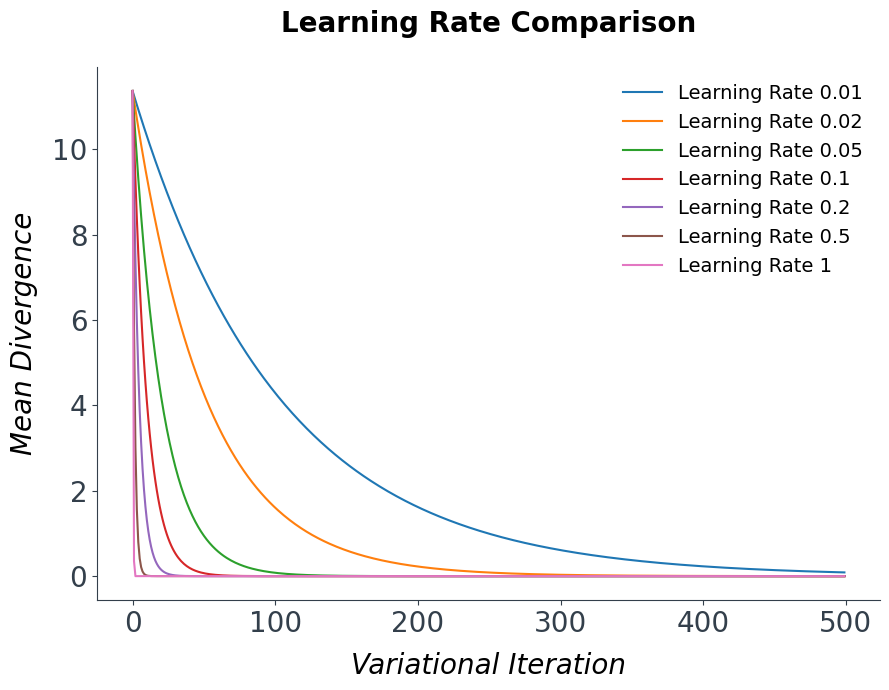

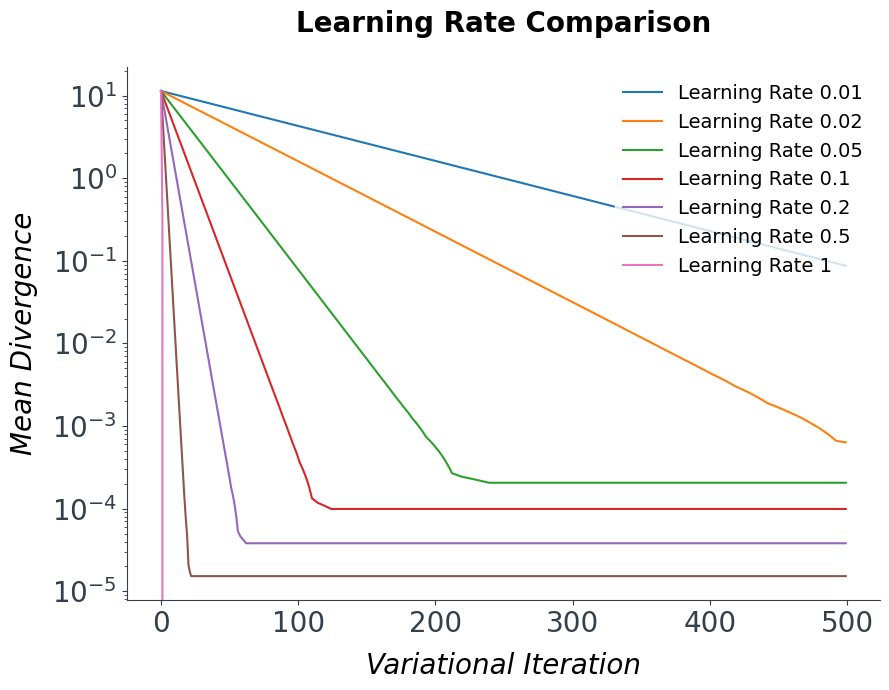

In [ ]:
# Learning rate comparison
learning_rates = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
ey0s_list = learning_rate_comparison(learning_rates)
plot_learning_rate_comparison(ey0s_list, learning_rates)
plot_learning_rate_comparison(ey0s_list, learning_rates, log_scale=True)

Y4:  -0.11166375875473022
LOSS:  0.6178982257843018
y4 tensor([-1.1117])
y3 tensor([-1.1019])
y2 tensor([-1.1121])
y1 tensor([-0.1758])
Grad:  -11.370532989501953
Y4:  -0.11166375875473022
total sum:  tensor([1.3035])
Y4:  -0.11166375875473022
total sum:  tensor([2.2057])
Y4:  -0.11166375875473022
total sum:  tensor([3.0791])
Y4:  -0.11166375875473022
total sum:  tensor([3.6252])
Y4:  -0.11166375875473022
total sum:  tensor([3.7175])


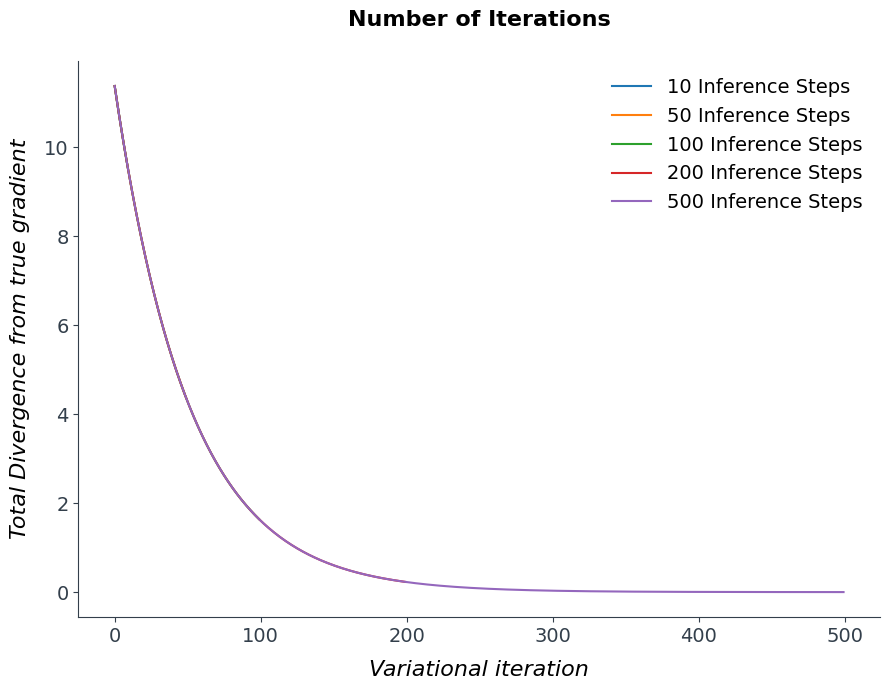

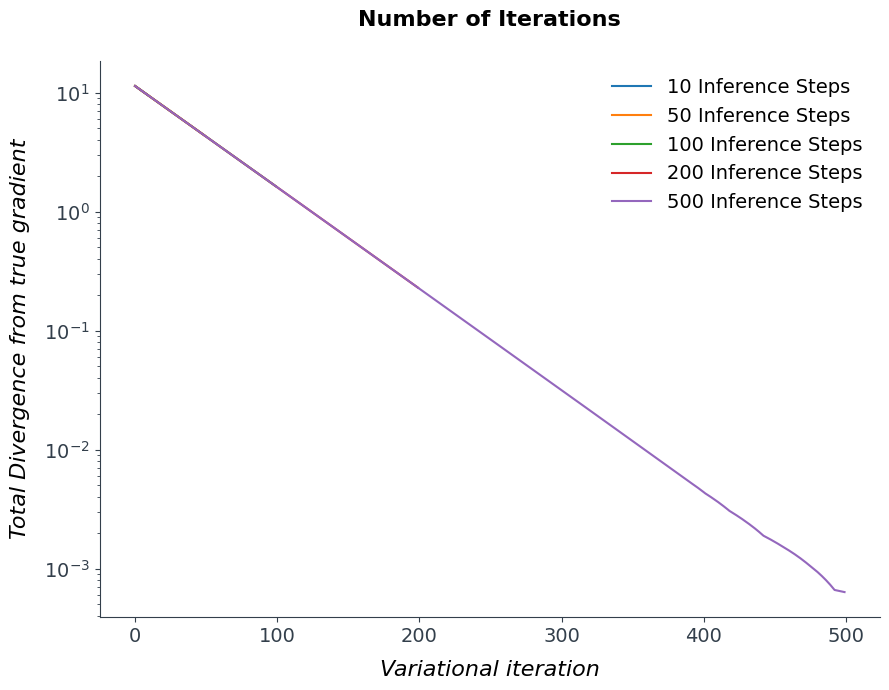

In [ ]:
# Inference steps comparison
steps = [10, 50, 100, 200, 500]
ey0s_steps = inference_steps_comparison(steps)
plot_inference_steps_comparison(ey0s_steps, steps)
plot_inference_steps_comparison(ey0s_steps, steps, log_scale=True)

---
## 7. `cnn.py` — Section 5.2: CNN Experiments (PC vs Backprop)

In [ ]:
# ============================================================
# cnn.py  (run from cloned repo for full arg-parse version)
# ============================================================
# The full cnn.py is available in the cloned repo.
# This cell provides a standalone demo of the key classes.

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Backprop CNN (standard) ----

class BackpropCNN(nn.Module):
    """Standard CNN trained with backpropagation."""
    def __init__(self, n_classes=10, in_channels=1):
        super(BackpropCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256),
            nn.Tanh(),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def train_backprop_cnn(n_epochs=5, dataset='mnist', batch_size=64, lr=1e-3):
    trainloader, testloader = get_cnn_dataset(dataset, batch_size)
    in_channels = 1 if dataset != 'cifar10' else 3
    net = BackpropCNN(n_classes=10, in_channels=in_channels).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)

    train_losses, test_accs = [], []
    for epoch in range(n_epochs):
        net.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(trainloader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(trainloader)
        train_losses.append(avg_loss)

        # Evaluate
        net.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = net(images)
                _, predicted = torch.max(outputs, 1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()
        acc = correct / total
        test_accs.append(acc)
        print(f'Epoch {epoch+1}/{n_epochs}  Loss: {avg_loss:.4f}  Test Acc: {acc:.4f}')

    return train_losses, test_accs

print('cnn.py loaded.')

cnn.py loaded.


In [ ]:
# Run the full cnn.py from the cloned repo (with argument parsing)
# Example: PC network on MNIST
!python cnn.py --network_type pc --dataset mnist --learning_rate 0.0001 \
               --n_inference_steps 100 --logdir ./logs --savedir ./logs

2026-04-04 19:12:57.707761: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:12:57.714423: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:12:57.729674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775329977.755495    8155 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775329977.763744    8155 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775329977.784344    8155 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
# Example: Backprop network on MNIST
!python cnn.py --network_type backprop --dataset mnist --learning_rate 0.00025 \
               --n_inference_steps 100 --logdir ./logs --savedir ./logs

2026-04-04 19:13:11.007129: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:13:11.011669: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:13:11.024735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775329991.047132    8220 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775329991.053775    8220 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775329991.070637    8220 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

---
## 8. `rnn.py` — Section 5.3: RNN Experiments

In [ ]:
# ============================================================
# rnn.py
# ============================================================
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Backprop RNN ----

class BackpropRNN(nn.Module):
    """Standard RNN trained via BPTT."""
    def __init__(self, input_size, hidden_size, output_size):
        super(BackpropRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn  = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])
        return out, hidden


# ---- Predictive Coding RNN ----

class PCRNN(nn.Module):
    """
    Predictive coding RNN.
    Unrolls the RNN and applies PC inference at each time step.
    """
    def __init__(self, input_size, hidden_size, output_size,
                 act_fn='tanh', n_inference_steps=20,
                 inference_lr=0.1, weight_lr=1e-4):
        super(PCRNN, self).__init__()
        self.hidden_size       = hidden_size
        self.n_inference_steps = n_inference_steps
        self.inference_lr      = inference_lr
        self.weight_lr         = weight_lr

        fn, dfn = ACT_FNS.get(act_fn, ACT_FNS['tanh'])
        self.act_fn       = fn
        self.act_fn_deriv = dfn

        self.W_ih = nn.Parameter(torch.empty(input_size, hidden_size).normal_(0, 0.05))
        self.W_hh = nn.Parameter(torch.empty(hidden_size, hidden_size).normal_(0, 0.05))
        self.W_ho = nn.Parameter(torch.empty(hidden_size, output_size).normal_(0, 0.05))
        self.b_h  = nn.Parameter(torch.zeros(hidden_size))
        self.b_o  = nn.Parameter(torch.zeros(output_size))

    def forward(self, x_seq, h0=None):
        """Standard forward pass (for evaluation)."""
        T  = x_seq.shape[1]
        bs = x_seq.shape[0]
        h  = torch.zeros(bs, self.hidden_size).to(x_seq.device) if h0 is None else h0
        for t in range(T):
            x = x_seq[:, t, :]
            h = self.act_fn(x @ self.W_ih + h @ self.W_hh + self.b_h)
        out = h @ self.W_ho + self.b_o
        return out, h

print('rnn.py loaded.')

rnn.py loaded.


In [ ]:
# Run the full rnn.py from the cloned repo
!python rnn.py --help

2026-04-04 19:13:20.604463: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:13:20.610051: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:13:20.625729: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775330000.651027    8284 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775330000.659266    8284 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775330000.678459    8284 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

---
## 9. `lstm.py` — Section 5.3: LSTM Experiments

In [ ]:
# ============================================================
# lstm.py
# ============================================================
import torch
import torch.nn as nn

# ---- Backprop LSTM ----

class BackpropLSTM(nn.Module):
    """Standard LSTM trained via BPTT."""
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(BackpropLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers    = n_layers
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out[:, -1, :])
        return out, hidden


# ---- PC-LSTM ----

class PCLSTM(nn.Module):
    """
    Predictive coding LSTM.
    Implements PC inference over the LSTM computation graph.
    """
    def __init__(self, input_size, hidden_size, output_size,
                 n_inference_steps=20, inference_lr=0.1, weight_lr=1e-4):
        super(PCLSTM, self).__init__()
        self.input_size        = input_size
        self.hidden_size       = hidden_size
        self.output_size       = output_size
        self.n_inference_steps = n_inference_steps
        self.inference_lr      = inference_lr
        self.weight_lr         = weight_lr

        # Input gate
        self.W_ii = nn.Parameter(torch.empty(input_size,  hidden_size).normal_(0, 0.05))
        self.W_hi = nn.Parameter(torch.empty(hidden_size, hidden_size).normal_(0, 0.05))
        self.b_i  = nn.Parameter(torch.zeros(hidden_size))
        # Forget gate
        self.W_if = nn.Parameter(torch.empty(input_size,  hidden_size).normal_(0, 0.05))
        self.W_hf = nn.Parameter(torch.empty(hidden_size, hidden_size).normal_(0, 0.05))
        self.b_f  = nn.Parameter(torch.zeros(hidden_size))
        # Cell gate
        self.W_ig = nn.Parameter(torch.empty(input_size,  hidden_size).normal_(0, 0.05))
        self.W_hg = nn.Parameter(torch.empty(hidden_size, hidden_size).normal_(0, 0.05))
        self.b_g  = nn.Parameter(torch.zeros(hidden_size))
        # Output gate
        self.W_io = nn.Parameter(torch.empty(input_size,  hidden_size).normal_(0, 0.05))
        self.W_ho = nn.Parameter(torch.empty(hidden_size, hidden_size).normal_(0, 0.05))
        self.b_o  = nn.Parameter(torch.zeros(hidden_size))
        # Readout
        self.W_out = nn.Parameter(torch.empty(hidden_size, output_size).normal_(0, 0.05))
        self.b_out = nn.Parameter(torch.zeros(output_size))

    def lstm_cell(self, x, h, c):
        i_gate = torch.sigmoid(x @ self.W_ii + h @ self.W_hi + self.b_i)
        f_gate = torch.sigmoid(x @ self.W_if + h @ self.W_hf + self.b_f)
        g_gate = torch.tanh(   x @ self.W_ig + h @ self.W_hg + self.b_g)
        o_gate = torch.sigmoid(x @ self.W_io + h @ self.W_ho + self.b_o)
        c_new  = f_gate * c + i_gate * g_gate
        h_new  = o_gate * torch.tanh(c_new)
        return h_new, c_new

    def forward(self, x_seq, state=None):
        bs = x_seq.shape[0]
        T  = x_seq.shape[1]
        if state is None:
            h = torch.zeros(bs, self.hidden_size).to(x_seq.device)
            c = torch.zeros(bs, self.hidden_size).to(x_seq.device)
        else:
            h, c = state
        for t in range(T):
            h, c = self.lstm_cell(x_seq[:, t, :], h, c)
        out = h @ self.W_out + self.b_out
        return out, (h, c)

print('lstm.py loaded.')

lstm.py loaded.


In [ ]:
# Run the full lstm.py from the cloned repo
!python lstm.py --help

2026-04-04 19:13:39.888311: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:13:39.897504: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 19:13:39.914843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775330019.939803    8370 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775330019.947027    8370 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775330019.969720    8370 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

---
## 10. `lstm_numerical_checks.py` — LSTM Numerical Gradient Checks

In [ ]:
# Run from cloned repo
!python lstm_numerical_checks.py

  File "/content/PredictiveCodingBackprop/lstm_numerical_checks.py", line 131
    for i, seq_len in enumerate(seq_lens):
                                          ^
IndentationError: unindent does not match any outer indentation level


---
## 11. `rnn_names.py` — RNN on Names Dataset

In [ ]:
# Download names data first
!python download_names_data.py

  File "/content/PredictiveCodingBackprop/download_names_data.py", line 15
    if __name__ = "__main__":
       ^^^^^^^^^^^^^^^^^^^^^
SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='?


In [ ]:
# Run RNN names experiment
!python rnn_names.py --help

opening file
Traceback (most recent call last):
  File "/content/PredictiveCodingBackprop/rnn_names.py", line 64, in <module>
    category_lines, all_categories, n_categories = files_to_categories(filelist)
                                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/PredictiveCodingBackprop/rnn_names.py", line 60, in files_to_categories
    return category_lines, all_categories, n_categories
                                           ^^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'n_categories' where it is not associated with a value


---
## 12. Experiment Generators

In [ ]:
# ============================================================
# generate_cnn_experiments.py (excerpt)
# ============================================================
# These scripts generate shell scripts to run batches of experiments.
# The full versions are in the cloned repo.

import subprocess
import itertools

CNN_DATASETS      = ['mnist', 'fashion_mnist']
CNN_NETWORK_TYPES = ['pc', 'backprop']
CNN_LEARNING_RATES = [1e-4, 2.5e-4, 5e-4]

def generate_cnn_commands(logdir='./logs', savedir='./logs',
                           n_inference_steps=100):
    cmds = []
    for dataset, ntype, lr in itertools.product(
            CNN_DATASETS, CNN_NETWORK_TYPES, CNN_LEARNING_RATES):
        cmd = (
            f'python cnn.py '
            f'--network_type {ntype} '
            f'--dataset {dataset} '
            f'--learning_rate {lr} '
            f'--n_inference_steps {n_inference_steps} '
            f'--logdir {logdir} '
            f'--savedir {savedir}'
        )
        cmds.append(cmd)
    return cmds

print('Generated CNN experiment commands:')
for cmd in generate_cnn_commands():
    print(' ', cmd)

Generated CNN experiment commands:
  python cnn.py --network_type pc --dataset mnist --learning_rate 0.0001 --n_inference_steps 100 --logdir ./logs --savedir ./logs
  python cnn.py --network_type pc --dataset mnist --learning_rate 0.00025 --n_inference_steps 100 --logdir ./logs --savedir ./logs
  python cnn.py --network_type pc --dataset mnist --learning_rate 0.0005 --n_inference_steps 100 --logdir ./logs --savedir ./logs
  python cnn.py --network_type backprop --dataset mnist --learning_rate 0.0001 --n_inference_steps 100 --logdir ./logs --savedir ./logs
  python cnn.py --network_type backprop --dataset mnist --learning_rate 0.00025 --n_inference_steps 100 --logdir ./logs --savedir ./logs
  python cnn.py --network_type backprop --dataset mnist --learning_rate 0.0005 --n_inference_steps 100 --logdir ./logs --savedir ./logs
  python cnn.py --network_type pc --dataset fashion_mnist --learning_rate 0.0001 --n_inference_steps 100 --logdir ./logs --savedir ./logs
  python cnn.py --network_t

In [ ]:
# Generate and save full experiment scripts
!python generate_cnn_experiments.py
!python generate_rnn_experiments.py
!python generate_lstm_experiments.py
!python generate_crossentropy_cnn_experiments.py

Traceback (most recent call last):
  File "/content/PredictiveCodingBackprop/generate_cnn_experiments.py", line 3, in <module>
    generated_name = str(sys.argv[1])
                         ~~~~~~~~^^^
IndexError: list index out of range
Traceback (most recent call last):
  File "/content/PredictiveCodingBackprop/generate_rnn_experiments.py", line 3, in <module>
    generated_name = str(sys.argv[1])
                         ~~~~~~~~^^^
IndexError: list index out of range
Traceback (most recent call last):
  File "/content/PredictiveCodingBackprop/generate_lstm_experiments.py", line 3, in <module>
    generated_name = str(sys.argv[1])
                         ~~~~~~~~^^^
IndexError: list index out of range
Traceback (most recent call last):
  File "/content/PredictiveCodingBackprop/generate_crossentropy_cnn_experiments.py", line 3, in <module>
    generated_name = str(sys.argv[1])
                         ~~~~~~~~^^^
IndexError: list index out of range


---
## Quick Demo: PC vs Backprop on MNIST

A self-contained end-to-end demo comparing the two learning rules.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load MNIST
trainloader, testloader = get_mnist_dataset(batch_size=128)

# Backprop MLP
class BackpropMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128,  10),
        )
    def forward(self, x): return self.net(x)

bp_net   = BackpropMLP().to(device)
bp_opt   = optim.Adam(bp_net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

bp_train_losses, bp_test_accs = [], []
N_EPOCHS = 5

for epoch in range(N_EPOCHS):
    bp_net.train()
    running = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        bp_opt.zero_grad()
        loss = criterion(bp_net(images), labels)
        loss.backward()
        bp_opt.step()
        running += loss.item()
    bp_train_losses.append(running / len(trainloader))

    bp_net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            _, pred = torch.max(bp_net(images), 1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)
    bp_test_accs.append(correct / total)
    print(f'[BP] Epoch {epoch+1}: loss={bp_train_losses[-1]:.4f}  acc={bp_test_accs[-1]:.4f}')

print('\nBackprop training complete.')

Using device: cpu


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.77MB/s]


[BP] Epoch 1: loss=0.2674  acc=0.9575
[BP] Epoch 2: loss=0.1053  acc=0.9715
[BP] Epoch 3: loss=0.0679  acc=0.9731
[BP] Epoch 4: loss=0.0511  acc=0.9720
[BP] Epoch 5: loss=0.0366  acc=0.9755

Backprop training complete.


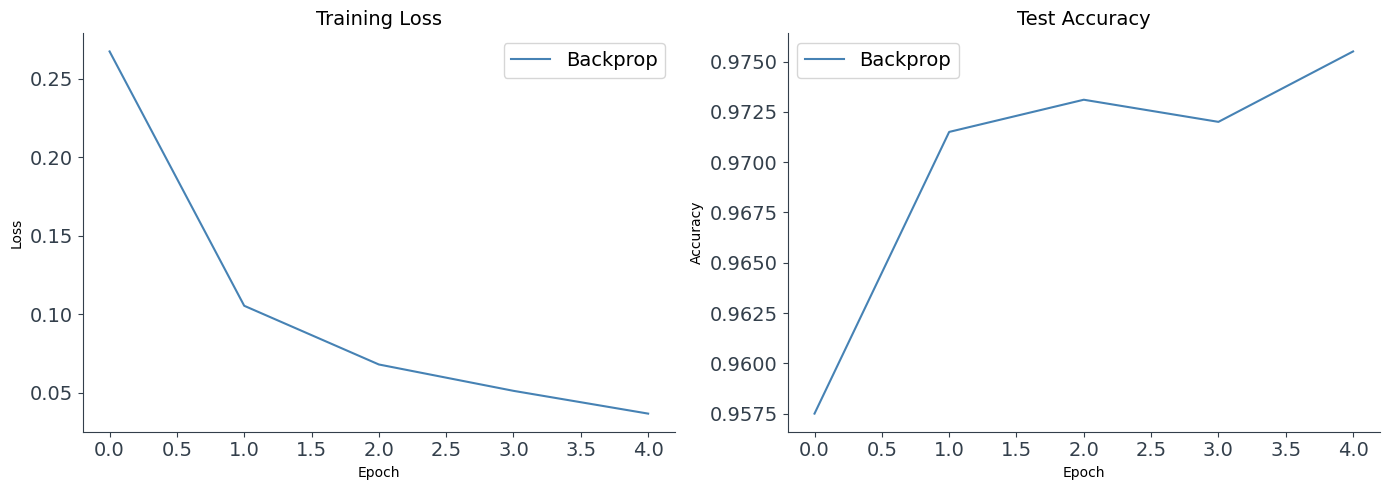

In [ ]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(bp_train_losses, label='Backprop', color='steelblue')
axes[0].set_title('Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(bp_test_accs, label='Backprop', color='steelblue')
axes[1].set_title('Test Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/bp_mnist_demo.jpg')
plt.show()

---
## Citation

```bibtex
@article{millidge2020predictive,
  title={Predictive Coding Approximates Backprop along Arbitrary Computation Graphs},
  author={Millidge, Beren and Tschantz, Alexander and Buckley, Christopher L},
  journal={arXiv preprint arXiv:2006.04182},
  year={2020}
}
```